# Calculus Refresher for Machine Learning

## Why This Matters

Neural networks learn through **optimization** — adjusting millions of parameters to minimize a loss function. Understanding how they find the best parameters requires understanding **calculus**.

In this notebook, we'll build intuition for:
- **Derivatives**: How functions change at a point
- **Chain rule**: The mathematical foundation of backpropagation
- **Partial derivatives**: Handling multiple inputs
- **Gradients**: The direction of steepest improvement

By the end, you'll understand why gradient descent works and how neural networks compute the gradients needed to learn.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Visualization settings
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

np.random.seed(42)

## 1. What is a Derivative?

### Intuition: Rate of Change

The **derivative** tells us how fast a function is changing at a specific point. 

Think of it as:
- **Driving**: Your speedometer shows your derivative with respect to time (miles per hour)
- **Hiking**: The steepness of a trail at your current location
- **ML**: How much the loss changes when you adjust a parameter slightly

Let's visualize this with a simple function: $f(x) = x^2$

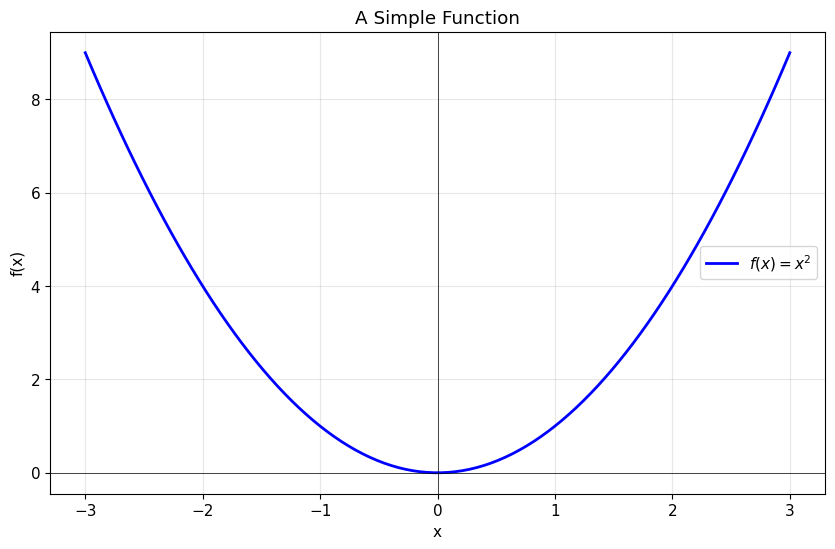

In [2]:
def f(x):
    """Simple quadratic function"""
    return x**2

# Plot the function
x = np.linspace(-3, 3, 100)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^2$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('A Simple Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

### Computing Derivatives Numerically

The derivative at a point is the **slope of the tangent line** at that point.

We can approximate it using a small change $h$:

$$f'(x) \approx \frac{f(x + h) - f(x)}{h}$$

Let's compute the derivative at $x = 1$:

In [3]:
def numerical_derivative(f, x, h=1e-5):
    """Approximate derivative using finite differences"""
    return (f(x + h) - f(x)) / h

# Compute derivative at x=1
x_point = 1.0
derivative = numerical_derivative(f, x_point)

print(f"f(x) = x^2")
print(f"Numerical derivative at x={x_point}: {derivative:.4f}")
print(f"Analytical derivative (2x) at x={x_point}: {2*x_point:.4f}")

f(x) = x^2
Numerical derivative at x=1.0: 2.0000
Analytical derivative (2x) at x=1.0: 2.0000


Perfect match! The numerical approximation matches the analytical formula $f'(x) = 2x$.

### Visualizing the Tangent Line

The derivative represents the **slope of the tangent line** — a line that just touches the curve at that point.

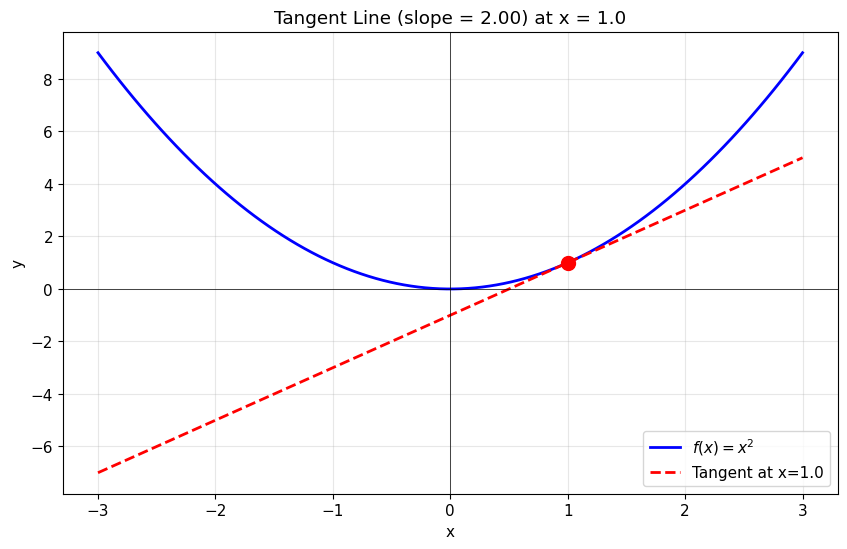

In [4]:
def plot_tangent_line(f, x_point, x_range=(-3, 3)):
    """Plot function and its tangent line at a point"""
    x = np.linspace(x_range[0], x_range[1], 100)
    y = f(x)
    
    # Compute derivative at point
    slope = numerical_derivative(f, x_point)
    y_point = f(x_point)
    
    # Tangent line: y = y_point + slope * (x - x_point)
    tangent_y = y_point + slope * (x - x_point)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^2$')
    plt.plot(x, tangent_y, 'r--', linewidth=2, label=f'Tangent at x={x_point}')
    plt.scatter([x_point], [y_point], color='red', s=100, zorder=5)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Tangent Line (slope = {slope:.2f}) at x = {x_point}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)
    plt.show()

plot_tangent_line(f, x_point=1.0)

### Derivatives at Different Points

The derivative changes depending on where we are on the curve. Let's explore how:

In [5]:
# Compute derivatives at multiple points
test_points = [-2, -1, 0, 1, 2]

print("x\tf(x)\tf'(x)\tInterpretation")
print("-" * 60)
for x_val in test_points:
    y_val = f(x_val)
    derivative = numerical_derivative(f, x_val)
    
    if derivative < 0:
        interpretation = "Decreasing (going down)"
    elif derivative > 0:
        interpretation = "Increasing (going up)"
    else:
        interpretation = "Flat (critical point)"
    
    print(f"{x_val}\t{y_val:.2f}\t{derivative:.2f}\t{interpretation}")

x	f(x)	f'(x)	Interpretation
------------------------------------------------------------
-2	4.00	-4.00	Decreasing (going down)
-1	1.00	-2.00	Decreasing (going down)
0	0.00	0.00	Increasing (going up)
1	1.00	2.00	Increasing (going up)
2	4.00	4.00	Increasing (going up)


**Key Insight**: 
- When $f'(x) < 0$: function is **decreasing** (going downhill)
- When $f'(x) > 0$: function is **increasing** (going uphill)  
- When $f'(x) = 0$: function is **flat** (potential minimum or maximum)

## 2. Common Derivative Rules

### Basic Rules You Need to Know

Instead of using numerical approximations, we can compute derivatives analytically using these rules:

| Function | Derivative |
|----------|------------|
| $f(x) = c$ (constant) | $f'(x) = 0$ |
| $f(x) = x$ | $f'(x) = 1$ |
| $f(x) = x^n$ | $f'(x) = n \cdot x^{n-1}$ (power rule) |
| $f(x) = e^x$ | $f'(x) = e^x$ |
| $f(x) = \ln(x)$ | $f'(x) = \frac{1}{x}$ |
| $f(x) = \sin(x)$ | $f'(x) = \cos(x)$ |
| $f(x) = \cos(x)$ | $f'(x) = -\sin(x)$ |

Let's verify these numerically:

In [6]:
x_test = 2.0

# Power rule: x^3
f_power = lambda x: x**3
numerical = numerical_derivative(f_power, x_test)
analytical = 3 * x_test**2
print(f"x^3 at x={x_test}:")
print(f"  Numerical: {numerical:.6f}")
print(f"  Analytical (3x^2): {analytical:.6f}")
print()

# Exponential: e^x
f_exp = lambda x: np.exp(x)
numerical = numerical_derivative(f_exp, x_test)
analytical = np.exp(x_test)
print(f"e^x at x={x_test}:")
print(f"  Numerical: {numerical:.6f}")
print(f"  Analytical (e^x): {analytical:.6f}")
print()

# Sine
f_sin = lambda x: np.sin(x)
numerical = numerical_derivative(f_sin, x_test)
analytical = np.cos(x_test)
print(f"sin(x) at x={x_test}:")
print(f"  Numerical: {numerical:.6f}")
print(f"  Analytical (cos(x)): {analytical:.6f}")

x^3 at x=2.0:
  Numerical: 12.000060
  Analytical (3x^2): 12.000000

e^x at x=2.0:
  Numerical: 7.389093
  Analytical (e^x): 7.389056

sin(x) at x=2.0:
  Numerical: -0.416151
  Analytical (cos(x)): -0.416147


Perfect! The analytical formulas match our numerical approximations.

### Derivative Operations

When combining functions, we can also combine their derivatives:

**Sum rule**: $(f + g)' = f' + g'$

**Product rule**: $(f \cdot g)' = f' \cdot g + f \cdot g'$

**Quotient rule**: $\left(\frac{f}{g}\right)' = \frac{f' \cdot g - f \cdot g'}{g^2}$

Let's verify the sum rule:

In [7]:
# Two simple functions
f1 = lambda x: x**2
f2 = lambda x: 3*x

# Their sum
f_sum = lambda x: f1(x) + f2(x)

x_test = 1.5

# Derivative of sum
deriv_sum = numerical_derivative(f_sum, x_test)

# Sum of derivatives
deriv_f1 = numerical_derivative(f1, x_test)  # Should be 2x = 3.0
deriv_f2 = numerical_derivative(f2, x_test)  # Should be 3
sum_of_derivs = deriv_f1 + deriv_f2

print(f"f(x) = x^2 + 3x at x={x_test}")
print(f"Derivative of sum: {deriv_sum:.4f}")
print(f"Sum of derivatives: {sum_of_derivs:.4f}")
print(f"They match: {np.allclose(deriv_sum, sum_of_derivs)}")

f(x) = x^2 + 3x at x=1.5
Derivative of sum: 6.0000
Sum of derivatives: 6.0000
They match: True


## 3. The Chain Rule: Foundation of Backpropagation

### Why the Chain Rule Matters

Neural networks are **nested functions** — the output of one layer feeds into the next:

$$\text{Input} \rightarrow \text{Layer 1} \rightarrow \text{Layer 2} \rightarrow \cdots \rightarrow \text{Output} \rightarrow \text{Loss}$$

To train them, we need to compute how the loss changes with respect to parameters in **any layer**. The **chain rule** tells us how to propagate derivatives backward through these nested functions.

### The Chain Rule Formula

If $y = f(g(x))$, then:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

In words: The rate of change of $y$ with respect to $x$ equals the rate of change of $y$ with respect to $g$ **times** the rate of change of $g$ with respect to $x$.

### Example: Nested Functions

Let's say $y = (2x + 1)^2$

We can think of this as:
- $g(x) = 2x + 1$ (inner function)
- $f(g) = g^2$ (outer function)
- $y = f(g(x))$ (composition)

Using the chain rule:
- $\frac{dg}{dx} = 2$
- $\frac{df}{dg} = 2g = 2(2x + 1)$
- $\frac{dy}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx} = 2(2x + 1) \cdot 2 = 4(2x + 1)$

In [8]:
# Define the composite function
def g(x):
    return 2*x + 1

def f(g_val):
    return g_val**2

def y(x):
    return f(g(x))

x_test = 1.0

# Numerical derivative of composite function
dy_dx_numerical = numerical_derivative(y, x_test)

# Using chain rule
dg_dx = 2  # derivative of g(x) = 2x + 1
g_val = g(x_test)
df_dg = 2 * g_val  # derivative of f(g) = g^2
dy_dx_chain = df_dg * dg_dx

# Analytical (expanding (2x+1)^2 and differentiating)
dy_dx_analytical = 4 * (2*x_test + 1)

print(f"y = (2x + 1)^2 at x={x_test}")
print(f"Numerical derivative: {dy_dx_numerical:.4f}")
print(f"Chain rule: {dy_dx_chain:.4f}")
print(f"Analytical: {dy_dx_analytical:.4f}")
print(f"\nAll methods agree: {np.allclose([dy_dx_numerical, dy_dx_chain, dy_dx_analytical], dy_dx_analytical)}")

y = (2x + 1)^2 at x=1.0
Numerical derivative: 12.0000
Chain rule: 12.0000
Analytical: 12.0000

All methods agree: True


### Visualizing the Chain Rule

Let's visualize how changes propagate through the nested functions:

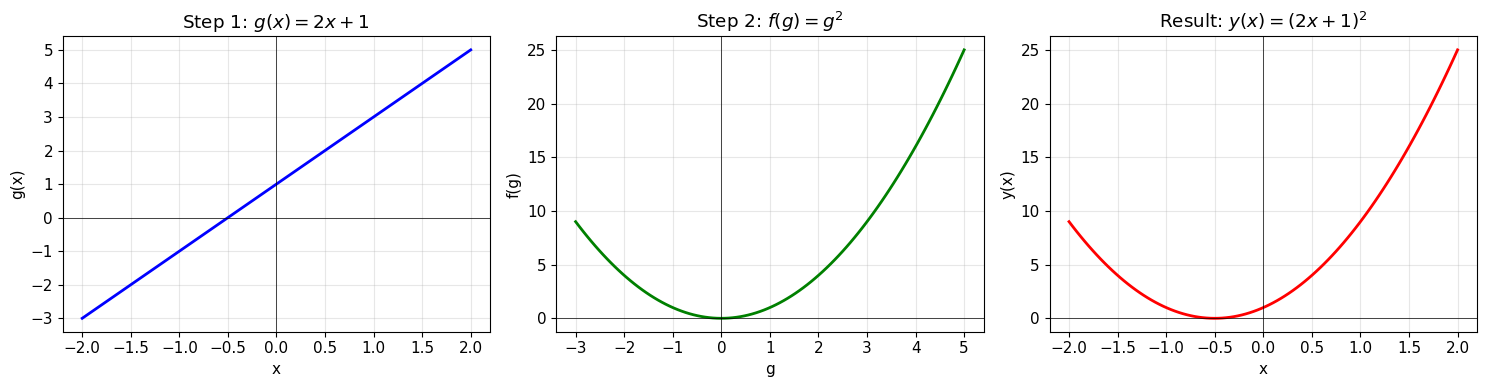

The chain rule tells us how to compute dy/dx by multiplying:
  dy/dx = (dy/dg) × (dg/dx)

This is exactly what backpropagation does in neural networks!


In [9]:
x_range = np.linspace(-2, 2, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot g(x)
axes[0].plot(x_range, g(x_range), 'b-', linewidth=2)
axes[0].set_title('Step 1: $g(x) = 2x + 1$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('g(x)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

# Plot f(g)
g_range = np.linspace(-3, 5, 100)
axes[1].plot(g_range, f(g_range), 'g-', linewidth=2)
axes[1].set_title('Step 2: $f(g) = g^2$')
axes[1].set_xlabel('g')
axes[1].set_ylabel('f(g)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

# Plot y(x) = f(g(x))
axes[2].plot(x_range, y(x_range), 'r-', linewidth=2)
axes[2].set_title('Result: $y(x) = (2x + 1)^2$')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y(x)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("The chain rule tells us how to compute dy/dx by multiplying:")
print("  dy/dx = (dy/dg) × (dg/dx)")
print("\nThis is exactly what backpropagation does in neural networks!")

### Deep Nesting: Multiple Layers

Neural networks have many layers. The chain rule extends naturally:

If $y = f_3(f_2(f_1(x)))$, then:

$$\frac{dy}{dx} = \frac{dy}{df_3} \cdot \frac{df_3}{df_2} \cdot \frac{df_2}{df_1} \cdot \frac{df_1}{dx}$$

Let's verify with $y = \sin(\exp(x^2))$:

In [10]:
# Three nested functions
def f1(x):
    return x**2

def f2(u):
    return np.exp(u)

def f3(v):
    return np.sin(v)

def y_nested(x):
    return f3(f2(f1(x)))

x_test = 0.5

# Numerical derivative
dy_dx_numerical = numerical_derivative(y_nested, x_test)

# Chain rule (working backward from output)
u = f1(x_test)        # u = x^2
v = f2(u)             # v = e^u
y_val = f3(v)         # y = sin(v)

df3_dv = np.cos(v)    # d(sin(v))/dv = cos(v)
df2_du = np.exp(u)    # d(e^u)/du = e^u
df1_dx = 2 * x_test   # d(x^2)/dx = 2x

# Multiply them all together (chain rule)
dy_dx_chain = df3_dv * df2_du * df1_dx

print(f"y = sin(exp(x^2)) at x={x_test}")
print(f"\nNumerical: {dy_dx_numerical:.6f}")
print(f"Chain rule: {dy_dx_chain:.6f}")
print(f"\nMatch: {np.allclose(dy_dx_numerical, dy_dx_chain)}")
print(f"\nThis is backpropagation through 3 layers!")

y = sin(exp(x^2)) at x=0.5

Numerical: 0.363192
Chain rule: 0.363195

Match: True

This is backpropagation through 3 layers!


**Key Insight**: Backpropagation is just the chain rule applied repeatedly, working backward from the output to the input. Each layer multiplies in its local derivative.

## 4. Partial Derivatives: Multiple Inputs

### Beyond Single Variables

Most ML functions have **multiple inputs**. For example, a loss function depends on predictions and labels. A linear layer depends on inputs and weights.

When a function has multiple inputs, we use **partial derivatives** — the derivative with respect to one variable while **holding others constant**.

For $f(x, y)$:
- $\frac{\partial f}{\partial x}$: how $f$ changes when we vary $x$ (keeping $y$ fixed)
- $\frac{\partial f}{\partial y}$: how $f$ changes when we vary $y$ (keeping $x$ fixed)

### Example: Simple Two-Variable Function

Let's use $f(x, y) = x^2 + xy + y^2$

Partial derivatives:
- $\frac{\partial f}{\partial x} = 2x + y$ (treating $y$ as constant)
- $\frac{\partial f}{\partial y} = x + 2y$ (treating $x$ as constant)

In [11]:
def f_two_vars(x, y):
    return x**2 + x*y + y**2

def partial_derivative_x(f, x, y, h=1e-5):
    """Partial derivative with respect to x (y held constant)"""
    return (f(x + h, y) - f(x, y)) / h

def partial_derivative_y(f, x, y, h=1e-5):
    """Partial derivative with respect to y (x held constant)"""
    return (f(x, y + h) - f(x, y)) / h

# Test at (x=1, y=2)
x_test, y_test = 1.0, 2.0

# Numerical
df_dx = partial_derivative_x(f_two_vars, x_test, y_test)
df_dy = partial_derivative_y(f_two_vars, x_test, y_test)

# Analytical
df_dx_analytical = 2*x_test + y_test  # 2x + y
df_dy_analytical = x_test + 2*y_test  # x + 2y

print(f"f(x, y) = x^2 + xy + y^2 at (x={x_test}, y={y_test})")
print(f"\nPartial derivative ∂f/∂x:")
print(f"  Numerical: {df_dx:.4f}")
print(f"  Analytical (2x + y): {df_dx_analytical:.4f}")
print(f"\nPartial derivative ∂f/∂y:")
print(f"  Numerical: {df_dy:.4f}")
print(f"  Analytical (x + 2y): {df_dy_analytical:.4f}")

f(x, y) = x^2 + xy + y^2 at (x=1.0, y=2.0)

Partial derivative ∂f/∂x:
  Numerical: 4.0000
  Analytical (2x + y): 4.0000

Partial derivative ∂f/∂y:
  Numerical: 5.0000
  Analytical (x + 2y): 5.0000


### Visualizing in 3D

For functions of two variables, we can visualize them as surfaces in 3D:

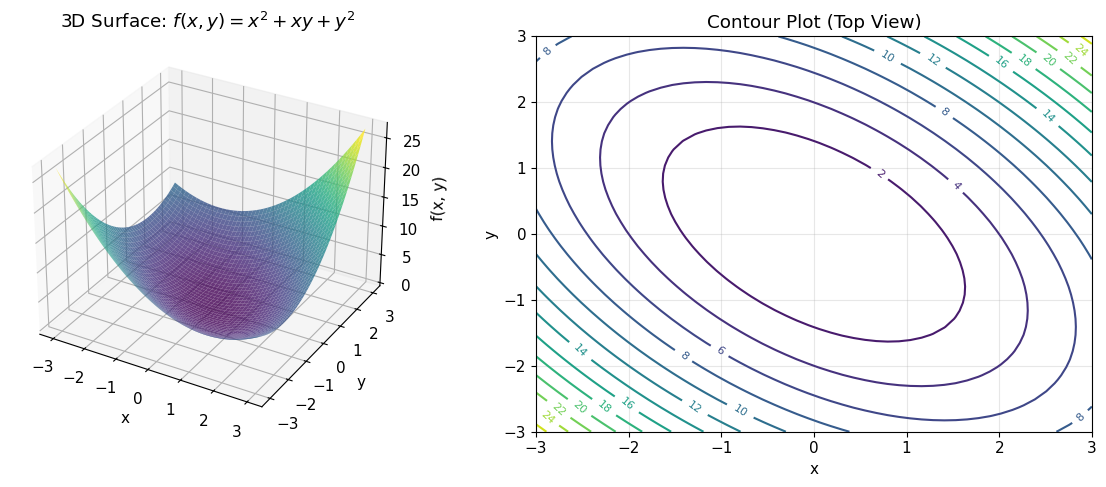

In [12]:
# Create a grid of x and y values
x_grid = np.linspace(-3, 3, 50)
y_grid = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f_two_vars(X, Y)

# Create 3D plot
fig = plt.figure(figsize=(12, 5))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.set_title('3D Surface: $f(x, y) = x^2 + xy + y^2$')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=15, cmap=cm.viridis)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot (Top View)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The **contour lines** show points where the function has the same value. Moving perpendicular to these lines changes the function value most rapidly.

## 5. Gradients: Direction of Steepest Ascent

### What is a Gradient?

The **gradient** is a vector of all partial derivatives:

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

The gradient points in the direction of **steepest increase**. Its magnitude tells us how steep that direction is.

**Critical insight for ML**: 
- The gradient points **uphill** (toward higher loss)
- The negative gradient points **downhill** (toward lower loss)
- Gradient descent moves in the **negative gradient direction** to minimize loss

In [13]:
def compute_gradient(f, x, y, h=1e-5):
    """Compute gradient vector [∂f/∂x, ∂f/∂y]"""
    df_dx = partial_derivative_x(f, x, y, h)
    df_dy = partial_derivative_y(f, x, y, h)
    return np.array([df_dx, df_dy])

# Compute gradient at several points
test_points = [(1, 1), (0, 1), (-1, 0), (0.5, -0.5)]

print("Gradients at different points:\n")
print("Point (x, y)\tf(x,y)\t\tGradient [∂f/∂x, ∂f/∂y]")
print("-" * 60)
for x, y in test_points:
    f_val = f_two_vars(x, y)
    grad = compute_gradient(f_two_vars, x, y)
    print(f"({x:4.1f}, {y:4.1f})\t{f_val:6.2f}\t\t[{grad[0]:6.2f}, {grad[1]:6.2f}]")

Gradients at different points:

Point (x, y)	f(x,y)		Gradient [∂f/∂x, ∂f/∂y]
------------------------------------------------------------
( 1.0,  1.0)	  3.00		[  3.00,   3.00]
( 0.0,  1.0)	  1.00		[  1.00,   2.00]
(-1.0,  0.0)	  1.00		[ -2.00,  -1.00]
( 0.5, -0.5)	  0.25		[  0.50,  -0.50]


### Visualizing Gradient Vectors

Let's plot the gradient vectors on our contour plot. The arrows show the direction of steepest ascent:

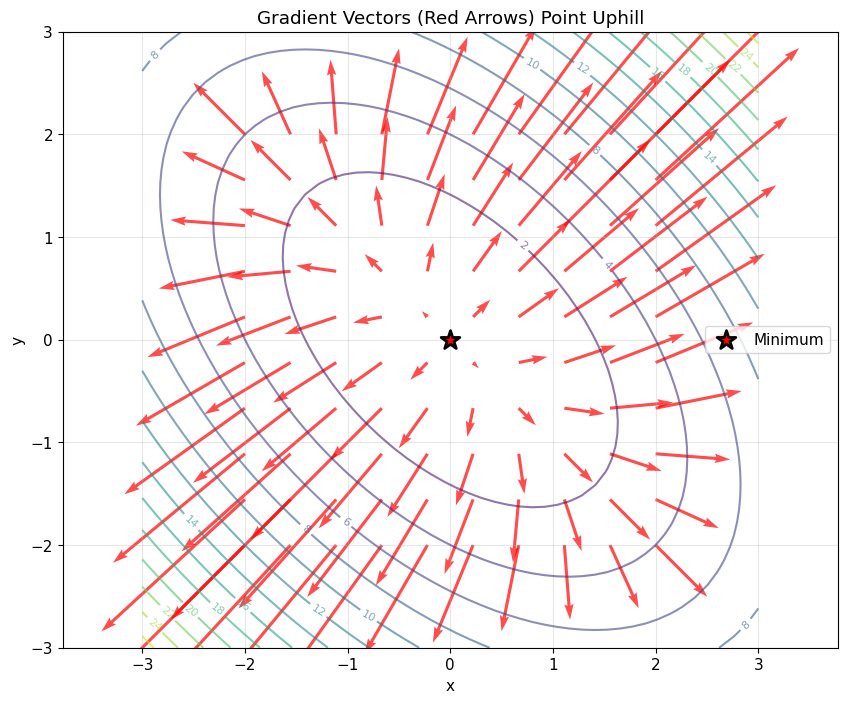


🔴 Red arrows = gradient direction (steepest ascent)
⭐ Red star = minimum (where gradients point outward)

To minimize, move OPPOSITE to gradient (gradient descent!)


In [14]:
# Create a sparser grid for gradient vectors
x_sparse = np.linspace(-2, 2, 10)
y_sparse = np.linspace(-2, 2, 10)

# Compute gradients at each point
gradients_x = np.zeros((len(y_sparse), len(x_sparse)))
gradients_y = np.zeros((len(y_sparse), len(x_sparse)))

for i, y in enumerate(y_sparse):
    for j, x in enumerate(x_sparse):
        grad = compute_gradient(f_two_vars, x, y)
        gradients_x[i, j] = grad[0]
        gradients_y[i, j] = grad[1]

X_sparse, Y_sparse = np.meshgrid(x_sparse, y_sparse)

# Plot
plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, Z, levels=15, cmap=cm.viridis, alpha=0.6)
plt.clabel(contour, inline=True, fontsize=8)

# Plot gradient vectors (scaled down for visibility)
plt.quiver(X_sparse, Y_sparse, gradients_x, gradients_y, 
           color='red', alpha=0.7, scale=30, width=0.004)

# Mark the minimum (approximately at origin)
plt.scatter([0], [0], color='red', s=200, marker='*', 
            label='Minimum', zorder=5, edgecolors='black', linewidths=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Vectors (Red Arrows) Point Uphill')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

print("\n🔴 Red arrows = gradient direction (steepest ascent)")
print("⭐ Red star = minimum (where gradients point outward)")
print("\nTo minimize, move OPPOSITE to gradient (gradient descent!)")

**Key Observations**:
1. Gradients point **away** from the minimum (uphill)
2. Gradients are **perpendicular** to contour lines
3. Gradient **magnitude** is larger where the surface is steeper
4. At the minimum, the gradient is **zero** (no preferred direction)

## 6. Connection to Optimization

### Gradient Descent Algorithm

Now we can understand **gradient descent** — the algorithm that trains neural networks:

1. Start at some point $(x, y)$
2. Compute the gradient $\nabla f(x, y)$
3. Move in the **opposite direction** (downhill): 
   $$\begin{bmatrix} x \\ y \end{bmatrix} \leftarrow \begin{bmatrix} x \\ y \end{bmatrix} - \alpha \nabla f(x, y)$$
4. Repeat until convergence

The parameter $\alpha$ is the **learning rate** — how big our steps are.

Let's implement this and watch it find the minimum:

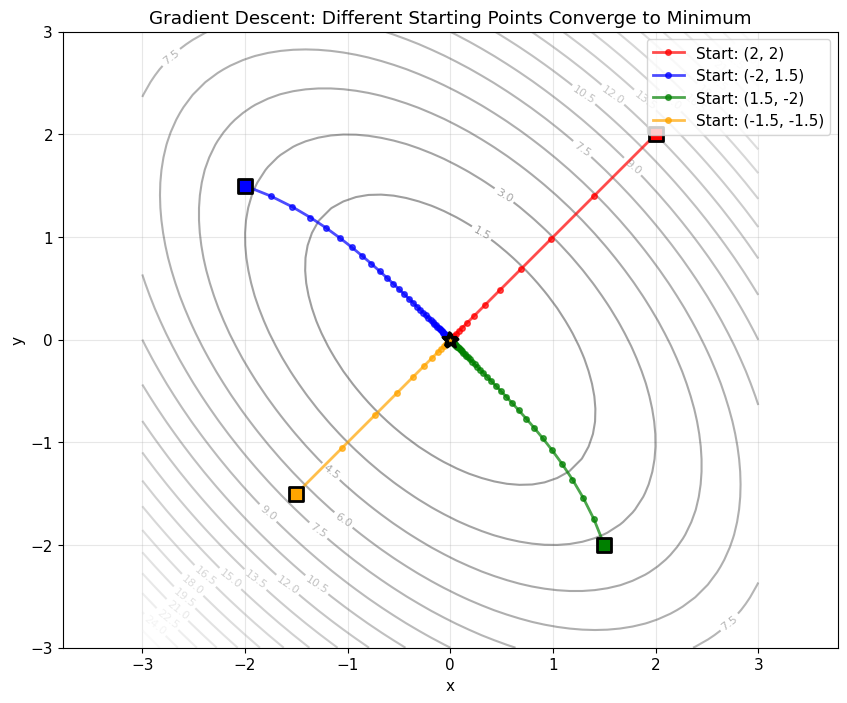


◼️  Square = starting point
⭐ Star = ending point (near minimum)

Gradient descent successfully finds the minimum from any starting point!


In [15]:
def gradient_descent(f, x_init, y_init, learning_rate=0.1, n_steps=50):
    """Run gradient descent to find minimum"""
    x, y = x_init, y_init
    path = [(x, y)]
    
    for _ in range(n_steps):
        # Compute gradient
        grad = compute_gradient(f, x, y)
        
        # Update (move opposite to gradient)
        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]
        
        path.append((x, y))
    
    return np.array(path)

# Start from different points
starting_points = [(2, 2), (-2, 1.5), (1.5, -2), (-1.5, -1.5)]
colors = ['red', 'blue', 'green', 'orange']

plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, Z, levels=20, cmap=cm.gray, alpha=0.4)
plt.clabel(contour, inline=True, fontsize=8)

for start_point, color in zip(starting_points, colors):
    path = gradient_descent(f_two_vars, start_point[0], start_point[1], 
                           learning_rate=0.1, n_steps=50)
    
    # Plot the path
    plt.plot(path[:, 0], path[:, 1], 'o-', color=color, 
             markersize=4, linewidth=2, alpha=0.7, label=f'Start: {start_point}')
    
    # Mark start and end
    plt.scatter(path[0, 0], path[0, 1], color=color, s=100, 
               marker='s', edgecolors='black', linewidths=2, zorder=5)
    plt.scatter(path[-1, 0], path[-1, 1], color=color, s=100, 
               marker='*', edgecolors='black', linewidths=2, zorder=5)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent: Different Starting Points Converge to Minimum')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print("\n◼️  Square = starting point")
print("⭐ Star = ending point (near minimum)")
print("\nGradient descent successfully finds the minimum from any starting point!")

### Effect of Learning Rate

The **learning rate** is crucial. Let's see what happens with different values:

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


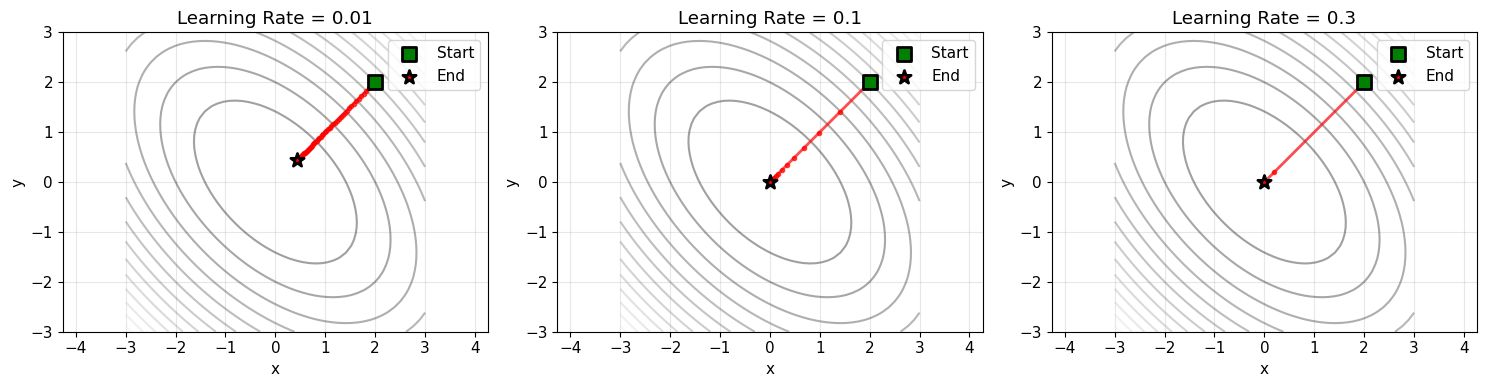

Observations:
• Small LR (0.01): Slow but steady convergence
• Medium LR (0.1): Fast and smooth convergence
• Large LR (0.3): Faster but can overshoot


In [16]:
learning_rates = [0.01, 0.1, 0.3]
start = (2, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr in zip(axes, learning_rates):
    path = gradient_descent(f_two_vars, start[0], start[1], 
                           learning_rate=lr, n_steps=50)
    
    # Plot contours
    contour = ax.contour(X, Y, Z, levels=15, cmap=cm.gray, alpha=0.4)
    
    # Plot path
    ax.plot(path[:, 0], path[:, 1], 'o-', color='red', 
           markersize=3, linewidth=2, alpha=0.7)
    ax.scatter(path[0, 0], path[0, 1], color='green', s=100, 
              marker='s', edgecolors='black', linewidths=2, zorder=5, label='Start')
    ax.scatter(path[-1, 0], path[-1, 1], color='red', s=100, 
              marker='*', edgecolors='black', linewidths=2, zorder=5, label='End')
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Learning Rate = {lr}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.axis('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

print("Observations:")
print("• Small LR (0.01): Slow but steady convergence")
print("• Medium LR (0.1): Fast and smooth convergence")
print("• Large LR (0.3): Faster but can overshoot")

### High-Dimensional Gradients

Neural networks have **millions of parameters**. The gradient is a vector with one component per parameter:

$$\nabla L = \begin{bmatrix} \frac{\partial L}{\partial w_1} \\ \frac{\partial L}{\partial w_2} \\ \vdots \\ \frac{\partial L}{\partial w_n} \end{bmatrix}$$

We can't visualize millions of dimensions, but the same principle applies:

In [17]:
# Simulate a high-dimensional problem
n_params = 1000  # Like a small neural network layer

# Random parameter initialization
params = np.random.randn(n_params)

# Simulate a gradient (random direction with some structure)
gradient = np.random.randn(n_params) * 0.1

print(f"Neural network parameters: {n_params}")
print(f"Gradient shape: {gradient.shape}")
print(f"\nGradient statistics:")
print(f"  Mean: {gradient.mean():.6f}")
print(f"  Std: {gradient.std():.6f}")
print(f"  Magnitude (L2 norm): {np.linalg.norm(gradient):.6f}")

# Gradient descent update
learning_rate = 0.01
params_new = params - learning_rate * gradient

print(f"\nAfter one gradient descent step:")
print(f"  Parameter change magnitude: {np.linalg.norm(params - params_new):.6f}")
print(f"\nThis is what happens EVERY step during neural network training!")

Neural network parameters: 1000
Gradient shape: (1000,)

Gradient statistics:
  Mean: 0.007084
  Std: 0.099696
  Magnitude (L2 norm): 3.160598

After one gradient descent step:
  Parameter change magnitude: 0.031606

This is what happens EVERY step during neural network training!


## 7. Key Takeaways

### Core Concepts

1. **Derivatives** measure rate of change
   - Positive: function increasing
   - Negative: function decreasing
   - Zero: potential minimum/maximum

2. **Chain Rule** enables backpropagation
   - Nested functions: multiply derivatives together
   - Critical for training deep networks
   - Work backward from output to input

3. **Partial Derivatives** handle multiple inputs
   - One derivative per input variable
   - Hold other variables constant
   - Essential for functions with many parameters

4. **Gradients** point uphill
   - Vector of all partial derivatives
   - Perpendicular to contour lines
   - Magnitude = steepness

5. **Gradient Descent** follows negative gradient
   - Move opposite to gradient (downhill)
   - Learning rate controls step size
   - Converges to local minimum

### Connection to Machine Learning

Now you understand the mathematical foundation of how neural networks learn:

1. **Forward pass**: Compute predictions and loss (nested functions)
2. **Backward pass**: Compute gradients using chain rule (backpropagation)
3. **Update**: Adjust parameters using negative gradient (gradient descent)
4. **Repeat**: Until loss is minimized

Every time a neural network trains, it's using these calculus principles millions of times!

### Visual Summary

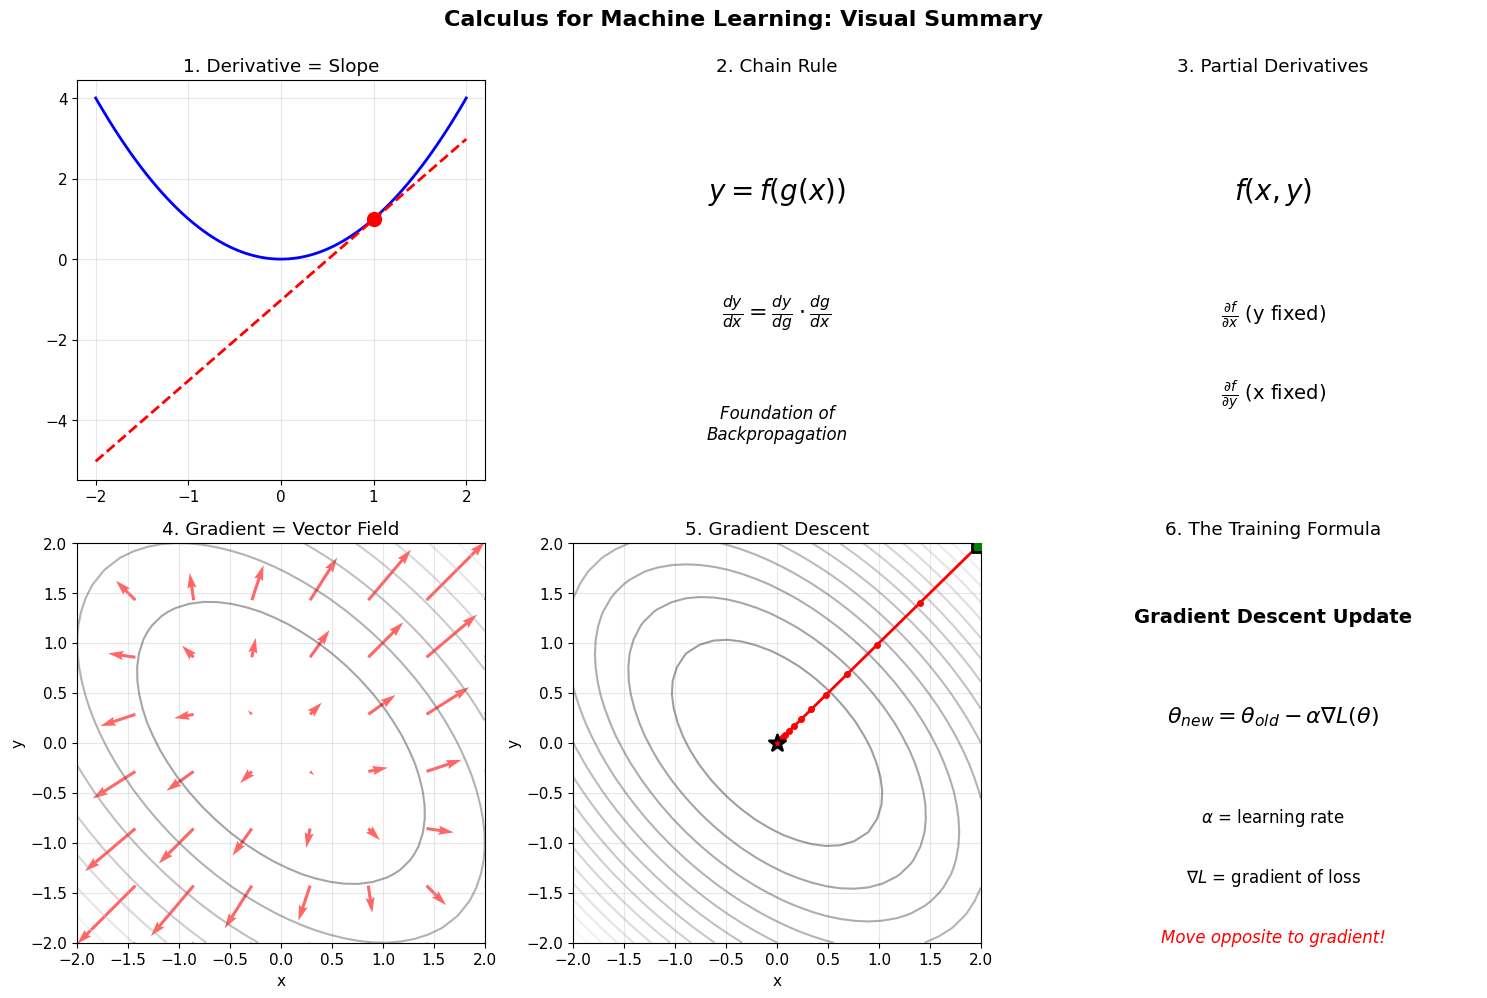


You now understand the mathematical foundation of deep learning!


In [18]:
# Create a summary visualization
fig = plt.figure(figsize=(15, 10))

# 1. Derivative as slope
ax1 = plt.subplot(2, 3, 1)
x = np.linspace(-2, 2, 100)
y = x**2
ax1.plot(x, y, 'b-', linewidth=2)
x_point = 1
slope = 2 * x_point
tangent = y[np.argmin(np.abs(x - x_point))] + slope * (x - x_point)
ax1.plot(x, tangent, 'r--', linewidth=2)
ax1.scatter([x_point], [x_point**2], color='red', s=100, zorder=5)
ax1.set_title('1. Derivative = Slope')
ax1.grid(True, alpha=0.3)

# 2. Chain rule
ax2 = plt.subplot(2, 3, 2)
ax2.text(0.5, 0.7, r'$y = f(g(x))$', ha='center', fontsize=20, weight='bold')
ax2.text(0.5, 0.4, r'$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$', 
         ha='center', fontsize=16)
ax2.text(0.5, 0.1, 'Foundation of\nBackpropagation', ha='center', fontsize=12, style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('2. Chain Rule')

# 3. Partial derivatives
ax3 = plt.subplot(2, 3, 3)
ax3.text(0.5, 0.7, r'$f(x, y)$', ha='center', fontsize=20, weight='bold')
ax3.text(0.5, 0.4, r'$\frac{\partial f}{\partial x}$ (y fixed)', ha='center', fontsize=14)
ax3.text(0.5, 0.2, r'$\frac{\partial f}{\partial y}$ (x fixed)', ha='center', fontsize=14)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')
ax3.set_title('3. Partial Derivatives')

# 4. Gradient vectors
ax4 = plt.subplot(2, 3, 4)
x_range = np.linspace(-2, 2, 30)
y_range = np.linspace(-2, 2, 30)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = f_two_vars(X_grid, Y_grid)
contour = ax4.contour(X_grid, Y_grid, Z_grid, levels=10, alpha=0.4, cmap=cm.gray)
x_sparse = np.linspace(-2, 2, 8)
y_sparse = np.linspace(-2, 2, 8)
X_s, Y_s = np.meshgrid(x_sparse, y_sparse)
U = 2*X_s + Y_s
V = X_s + 2*Y_s
ax4.quiver(X_s, Y_s, U, V, color='red', alpha=0.6, scale=30)
ax4.set_title('4. Gradient = Vector Field')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.grid(True, alpha=0.3)

# 5. Gradient descent
ax5 = plt.subplot(2, 3, 5)
path = gradient_descent(f_two_vars, 2, 2, learning_rate=0.1, n_steps=30)
contour = ax5.contour(X_grid, Y_grid, Z_grid, levels=15, alpha=0.4, cmap=cm.gray)
ax5.plot(path[:, 0], path[:, 1], 'ro-', linewidth=2, markersize=4)
ax5.scatter(path[0, 0], path[0, 1], color='green', s=150, marker='s', 
           edgecolors='black', linewidths=2, zorder=5)
ax5.scatter(path[-1, 0], path[-1, 1], color='red', s=150, marker='*', 
           edgecolors='black', linewidths=2, zorder=5)
ax5.set_title('5. Gradient Descent')
ax5.set_xlabel('x')
ax5.set_ylabel('y')
ax5.grid(True, alpha=0.3)

# 6. Key formula
ax6 = plt.subplot(2, 3, 6)
ax6.text(0.5, 0.8, 'Gradient Descent Update', ha='center', fontsize=14, weight='bold')
ax6.text(0.5, 0.55, r'$\theta_{new} = \theta_{old} - \alpha \nabla L(\theta)$', 
         ha='center', fontsize=16)
ax6.text(0.5, 0.3, r'$\alpha$ = learning rate', ha='center', fontsize=12)
ax6.text(0.5, 0.15, r'$\nabla L$ = gradient of loss', ha='center', fontsize=12)
ax6.text(0.5, 0.0, 'Move opposite to gradient!', ha='center', fontsize=12, 
         style='italic', color='red')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')
ax6.set_title('6. The Training Formula')

plt.suptitle('Calculus for Machine Learning: Visual Summary', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("You now understand the mathematical foundation of deep learning!")
print("="*60)

## Next Steps

Now that you understand calculus fundamentals, you're ready to:

1. **Study backpropagation**: See how the chain rule computes gradients in neural networks
2. **Learn about optimizers**: Understand how Adam, SGD, and other algorithms improve on basic gradient descent
3. **Explore automatic differentiation**: See how PyTorch computes gradients automatically
4. **Build neural networks**: Apply these concepts to train real models

The calculus never goes away — it's happening behind the scenes every time a neural network learns!